# Haematology

Collaboration with Ahmed Dawoud and Owen Rackham on haematological malignancies related mutations. 

>Initially, I worked on finding driver somatic mutations (clonality marker) in the blood samples of  healthy people and finding their correlation with chronic inflammatory diseases (malignant/non-malignant diseases).
Despite, the association of these mutations with haematological malignancies, but the majority of people who acquire these mutations does not develop diseases !!!!!!
 
> There is a list of targeted genes that we, and others had identified in UK Biobank. 6% of UK Biobank participants are carriers for driver mutations, but, the majority (>90%) of driver mutations identified in small list of genes, mainly epigenetic regulator genes  (DNMT3A, TET2, and ASXL1)
 
> I will put initially three aims:
> 1.	Does personalized VEP significantly different in comparison to traditional VEP for these genes (let’s start by CADD)?
> 2.	What are the protein domains that cause this modification.
> 3.	Can we improve the calling of driver mutations in these genes?. The current practice depends on using a mix of filters, pathogenicity score, and the correlation with age


In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og
import src.colabfold as cf
import src.unitprot as up

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import numpy as np  

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [3]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 681512 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [ ]:
genes = ['DNMT3A','TET2','ASXL1']

pg_resources = pg.merge_resources()
pg_resources = pg_resources.loc[pg_resources['genename'].isin(genes)]
refseq_ids_dict = dict(zip(pg_resources['genename'], pg_resources['protein']))
refseq_ids_dict 

ProteinGym: Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

{'DNMT3A': 'NP_783328.1', 'TET2': 'NP_001120680.1'}

In [25]:

vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']=="esm2_t33_650M_UR50D") & 
                            (vep_files['protein'].isin(refseq_ids_dict.values()))]
    )
vep_df["HGNC"] = vep_df["GENEINFO"].str.split(":").str[0] 
vep_df.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 127 masked-marginals parquet files


Reading files:   0%|          | 0/127 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 9.05GB/s]


VEP dataframe shape: (3632, 72)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC
0,ENSP00000442788:REF,NP_001120680.1,MEQDRTNHVEGNRLSPFLIPSPPICQTEPLATKLQNGSPLPERAHP...,H8D,MEQDRTNDVEGNRLSPFLIPSPPICQTEPLATKLQNGSPLPERAHP...,Benign,0.115010,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000442788,ENST00000540549,False,4,105233964,2061159,C,G,.,PASS,2061159,4:105233964,G,54790,NM_001127208.3,Transcript,missense_variant,318,22,8,H/D,Cat/Gat,-,MODERATE,-,1,-,-,-,C,C,-,NM_001127208.3:c.22C>G,NP_001120680.1:p.His8Asp,-,NaN,NaN,2127726,MedGen:CN517202,not_provided,NC_000004.12:g.105233964C>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,TET2:54790|TET2-AS1:104384744,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.134527,NaN,2,likely_benign,TET2
1,ENSP00000442788:REF,NP_001120680.1,MEQDRTNHVEGNRLSPFLIPSPPICQTEPLATKLQNGSPLPERAHP...,P29R,MEQDRTNHVEGNRLSPFLIPSPPICQTERLATKLQNGSPLPERAHP...,Benign,-0.545321,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000442788,ENST00000540549,False,4,105234028,135316,C,G,.,PASS,135316,4:105234028,G,54790,NM_001127208.3,Transcript,missense_variant,382,86,29,P/R,cCt/cGt,-,MODERATE,-,1,-,-,-,C,C,-,NM_001127208.3:c.86C>G,NP_001120680.1:p.Pro29Arg,-,0.02038,0.06057,139055,MedGen:CN169374|MedGen:CN517202,not_specified|not_provided,NC_000004.12:g.105234028C>G,"criteria_provided,_single_submitter",Benign,NaN,single_nucleotide_variant,SO:0001483,TET2:54790|TET2-AS1:104384744,SO:0001583|missense_variant,1,12498609,0.09245,ClinGen:CA162345|UniProtKB:Q6N021#VAR_039841,NaN,NaN,NaN,NaN,NaN,-0.616655,NaN,2,benign,TET2
2,ENSP00000442788:REF,NP_001120680.1,MEQDRTNHVEGNRLSPFLIPSPPICQTEPLATKLQNGSPLPERAHP...,L34F,MEQDRTNHVEGNRLSPFLIPSPPICQTEPLATKFQNGSPLPERAHP...,Benign,-1.407017,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000442788,ENST00000540549,False,4,105234042,135308,C,T,.,PASS,135308,4:105234042,T,54790,NM_001127208.3,Transcript,missense_variant,396,100,34,L/F,Ctc/Ttc,-,MODERATE,-,1,-,-,-,C,C,-,NM_001127208.3:c.100C>T,NP_001120680.1:p.Leu34Phe,-,0.01430,0.01530,139047,MedGen:CN169374|MedGen:CN517202,not_specified|not_provided,NC_000004.12:g.105234042C>T,"criteria_provided,_single_submitter",Benign,NaN,single_nucleotide_variant,SO:0001483,TET2:54790|TET2-AS1:104384744,SO:0001583|missense_variant,1,111948941,0.00639,ClinGen:CA162305|UniProtKB:Q6N021#VAR_058171,NaN,NaN,NaN,NaN,NaN,-1.196760,NaN,2,benign,TET2
3,ENSP00000442788:REF,NP_001120680.1,MEQDRTNHVEGNRLSPFLIPSPPICQTEPLATKLQNGSPLPERAHP...,S145N,MEQDRTNHVEGNRLSPFLIPSPPICQTEPLATKLQNGSPLPERAHP...,Benign,-0.841569,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000442788,ENST00000540549,False,4,105234376,135320,G,A,.,PASS,135320,4:105234376,A,54790,NM_001127208.3,Transcript,missense_variant,730,434,145,S/N,aGt/aAt,-,MODERATE,-,1,-,-,-,G,G,-,NM_001127208.3:c.434G>A,NP_001120680.1:p.Ser145Asn,-,0.00238,0.00066,139059,MedGen:CN517202|MedGen:CN169374,not_provided|not_specified,NC_000004.12:g.105234376G>A,"criteria_provided,_single_submitter",Benign,NaN,single_nucleotide_variant,SO:0001483,TET2:54790|TET2-AS1:104384744,SO:0001583|missense_variant,1,114619974,0.00240,ClinGen:CA162365|UniProtKB:Q6N021#VAR_058172,NaN,NaN,NaN,NaN,NaN,-0.882614,NaN,2,benign,TET2
4,ENSP00

In [30]:
vep_df.groupby(["HGNC",'clinsig'])["mutant"].nunique().reset_index()

,HGNC,clinsig,mutant
0,DNMT3A,benign,1
1,DNMT3A,likely_benign,6
2,DNMT3A,likely_path,24
3,DNMT3A,path,10
4,TET2,benign,18
5,TET2,likely_benign,7
6,TET2,path,1


## Compute within-site variance

In [32]:
within_site_var, within_site_var_mean = va.get_mondo_within_site_var(vep_df=vep_df)
within_site_var.head()

Extracting 1 ID column(s).
Extracting MONDO IDs.
Adding MONDO count column.


,MONDO,MONDO_split,model_location,clinsig,protein,ENSP,GENEINFO,RS,mutant,scoring_strategy,VEP,haplotype,MONDO_label
0,MONDO:0001071,MONDO:0001071,esm2_t33_650M_UR50D,likely_path,NP_783328.1,ENSP00000264709,DNMT3A:1788,1558650788,Y908N,masked-marginals,0.103846,22,intellectual disability
7,MONDO:0014382,MONDO:0014382,esm2_t33_650M_UR50D,likely_path,NP_783328.1,ENSP00000264709,DNMT3A:1788,1573297136,T832I,masked-marginals,0.050796,22,Tatton-Brown-Rahman overgrowth syndrome
3,MONDO:0014382,MONDO:0014382,esm2_t33_650M_UR50D,likely_benign,NP_783328.1,ENSP00000264709,DNMT3A:1788,149738328,N501S,masked-marginals,0.047210,22,Tatton-Brown-Rahman overgrowth syndrome
9,MONDO:0014382,MONDO:0014382,esm2_t33_650M_UR50D,path,NP_783328.1,ENSP00000264709,DNMT3A:1788,757823678,R771Q,masked-marginals,0.035108,22,Tatton-Brown-Rahman overgrowth syndrome
6,MONDO:0014382,MONDO:0014382,esm2_t33_650M_UR50D,likely_path,NP_783328.1,ENSP00000264709,DNMT3A:1788,1553412485,E545G,masked-marginals,0.032189,22,Tatton-Brown-Rahman overgrowth syndrome


## DNMT3A

Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    5
1000GENOMES:phase_3:EUR    5
1000GENOMES:phase_3:AMR    2
1000GENOMES:phase_3:EAS    2
1000GENOMES:phase_3:SAS    1
Name: count, dtype: int64

Percentage of population-specific haplotypes: 68.18%


<string>:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


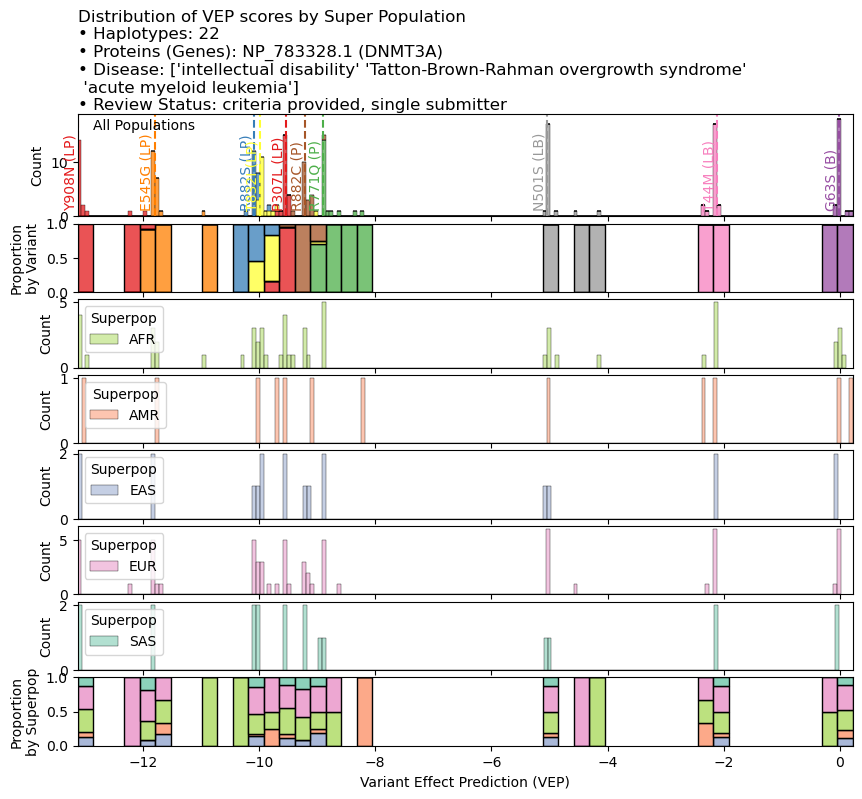

In [53]:
plot_df = va.plot_vep_by_superpop(vep_df=vep_df.loc[vep_df['HGNC']=="DNMT3A"], 
                                  remove_zeros=False,
                                  within_site_var=within_site_var, 
                                  i=range(10),     
                                #   haps_to_samples=haps_to_samples,
                                  figsize=(10, 8),
                                  palette="Set1", 
                                  hue_top="mutant",
                                  hue="Super Population", 
                                  hue_bottom="Super Population",
                                  
                                  unique_haplotypes = True)

## TET2

plot_df.shape: (2730, 76)
Adding haplotype frequencies.


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    29
1000GENOMES:phase_3:AMR    17
1000GENOMES:phase_3:EAS    15
1000GENOMES:phase_3:SAS     9
1000GENOMES:phase_3:EUR     6
Name: count, dtype: int64

Percentage of population-specific haplotypes: 72.38%


<string>:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


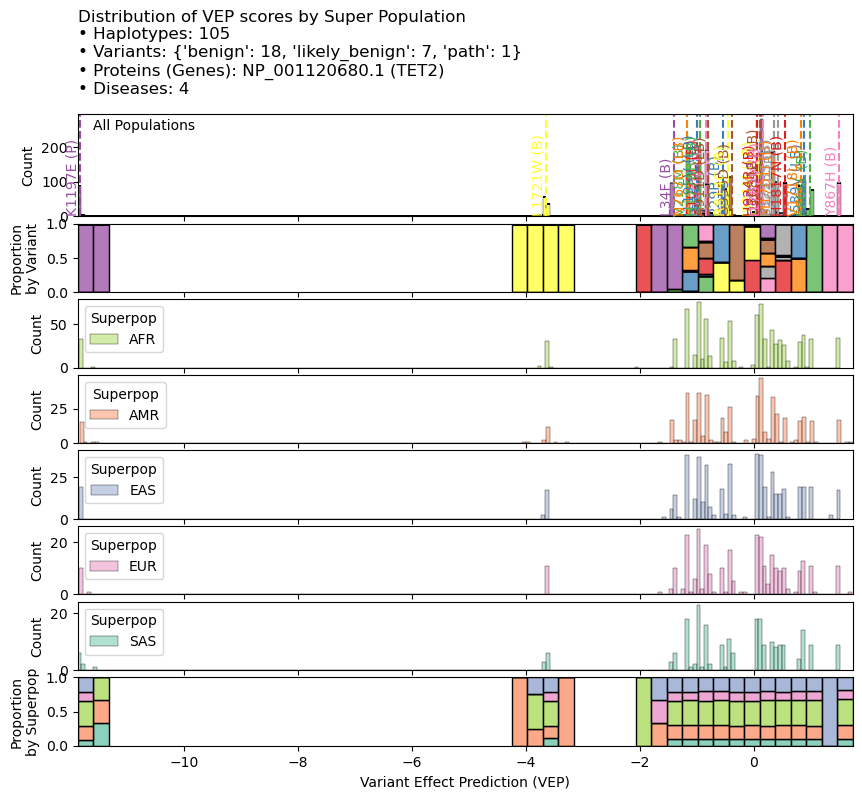

In [74]:
plot_df = va.plot_vep_by_superpop(vep_df=vep_df.loc[vep_df['HGNC']=="TET2"], 
                                  remove_zeros=False,
                                  # within_site_var=within_site_var,  # There's no within-site var for TET2 (due to lack of MONDO labels)
                                  figsize=(10, 8),
                                  palette="Set1", 
                                  hue_top="mutant",
                                  hue="Super Population", 
                                  hue_bottom="Super Population",
                                  
                                  unique_haplotypes = True)